In [7]:
# ── Standard library ───────────────────────────────────────────────────────────
import os
import math
import textwrap
# import pdb  # uncomment when debugging
from statistics import mean
# ── Data & preprocessing ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
# ── Statistics ────────────────────────────────────────────────────────────────
from scipy import stats  # if you use stats.ttest_ind, stats.shapiro, etc.
from scipy.stats import (  # if you call functions directly: ttest_ind(...), etc.
    ttest_ind,
    spearmanr,
    pearsonr,
    chi2,
    zscore,
    shapiro,
    normaltest,
    levene, ttest_ind, 
    mannwhitneyu
)
# ── Modeling ─────────────────────────────────────────────────────────────────
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pymer4.models import Lmer 

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches  # custom legend patches
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Define the directory where the files are saved
directory = 'data'

# Define file paths for each CSV file
file_paths = {
    "relativeShift_OCD": os.path.join(directory, 'CrypticCreaturesBayesianLearner_relativeShift_OCD.csv'),
    "relativeShift_controls": os.path.join(directory, 'CrypticCreaturesBayesianLearner_relativeShift_controls.csv'),
    "relativeED_OCD": os.path.join(directory, 'CrypticCreaturesBayesianLearner_relativeED_OCD.csv'),
    "relativeED_controls": os.path.join(directory, 'CrypticCreaturesBayesianLearner_relativeED_controls.csv'),
    "relativeID_OCD": os.path.join(directory, 'CrypticCreaturesBayesianLearner_relativeID_OCD.csv'),
    "relativeID_controls": os.path.join(directory, 'CrypticCreaturesBayesianLearner_relativeID_controls.csv'),
    "CrypticCreatures": os.path.join(directory, 'CrypticCreatures_BayesianLearner.csv')
}

# Read each CSV file into a dictionary of DataFrames
dataframes = {}
for name, path in file_paths.items():
    if os.path.exists(path):
        dataframes[name] = pd.read_csv(path)
    else:
        print(f"Error: File not found - {path}")
    
CrypticCreatures_adapted = dataframes["CrypticCreatures"]

Data prep

In [8]:
# Sort the DataFrame by 'id', 'task_id', 'run', and 'trial' to ensure correct order
CrypticCreatures_adapted = CrypticCreatures_adapted.sort_values(by=['id', 'task_id', 'run', 'trial']).reset_index(drop=True)
CrypticCreatures_adapted['total_iq'] = CrypticCreatures_adapted['icar_totalscore']

# Insert variable indicating task and block breaks
CrypticCreatures_adapted['task_break'] = ((CrypticCreatures_adapted['trial'] == 1) & (CrypticCreatures_adapted['run'] == 1)).astype(int)
CrypticCreatures_adapted['block_break'] = ((CrypticCreatures_adapted['trial'] == 1) & (CrypticCreatures_adapted['run'] == 2)).astype(int)

# Initialize empty columns for global_trial and task_trial
CrypticCreatures_adapted['global_trial'] = 0
CrypticCreatures_adapted['task_trial'] = 0

# Assign global trials and task-specific trials
for participant_id in CrypticCreatures_adapted['id'].unique():
    participant_data = CrypticCreatures_adapted[CrypticCreatures_adapted['id'] == participant_id]
    
    # Global trial counter (across all tasks and runs for this participant)
    global_trial_counter = 1
    
    for task in participant_data['task_id'].unique():
        task_data = participant_data[participant_data['task_id'] == task]
        task_trial_counter = 1  # Reset task-specific counter for each task_id
        
        for index in task_data.index:
            # Assign global_trial (continuous across all trials for the participant)
            CrypticCreatures_adapted.at[index, 'global_trial'] = global_trial_counter
            global_trial_counter += 1
            
            # Assign task_trial (continuous within each task_id across runs)
            CrypticCreatures_adapted.at[index, 'task_trial'] = task_trial_counter
            task_trial_counter += 1

# 1) Group by (id, task_id, run) to get the number of unique trials for each combination
grouped = CrypticCreatures_adapted.groupby(["id", "task_id", "run"])["trial"].nunique()

# 2) Pivot so that each row is one 'id' and columns represent (task_id, run)
df_check = grouped.unstack(level=["task_id", "run"]).fillna(0)
 
ocd_color = '#5f8cff'
control_color = '#b4a854'

# Define colors for all the plots
colors_palette = [
    '#7c242b',  # Soft Purple
    '#a37c64',  # Warm Brown
    '#a794ba',  # Muted Pink
    '#8a9f6a',  # Muted Green
    '#859ba3',  # Stone Gray
    '#9a8b4e',  # Olive Green
    '#7392c9',   # Slate Blue
    '#c64865',  # pink
    '#ec6a35'  # orange
]

In [9]:
# Compute average accuracy and confidence per id and task_id
avg_metrics_per_task = CrypticCreatures_adapted.groupby(['id', 'task_id']).agg(
    avg_accuracy=('chosen_outcome', 'mean'),
    avg_confidence=('confidence', 'mean'),
    avg_RT=('RT_log', 'mean')
).reset_index()

# Compute overall average accuracy and confidence per id across all task_ids
avg_metrics_overall = CrypticCreatures_adapted.groupby('id').agg(
    overall_avg_accuracy=('chosen_outcome', 'mean'),
    overall_avg_confidence=('confidence', 'mean'),
    overall_avg_RT=('RT_log', 'mean'),
    overall_av_repetErr=('repet_err_ed', 'mean'),
    overall_diff_BLR=('signed_confidence_deviation', 'mean'),
    overall_diff_sumprior=('signed_prior_deviation', 'mean'),
).reset_index()

# Merge back the per-task averages into the original DataFrame
CrypticCreatures_adapted = CrypticCreatures_adapted.merge(avg_metrics_per_task, on=['id', 'task_id'], how='left', suffixes=('', '_per_task'))

# Merge back the overall averages into the original DataFrame
CrypticCreatures_adapted = CrypticCreatures_adapted.merge(avg_metrics_overall, on='id', how='left', suffixes=('', '_overall'))


Some correlations

In [10]:
participant_id_col = 'id'                         # Column identifying participants
gc_col = 'prev_BLR_confidence'          # Column with ORIGINAL GC values
cc_col = 'sum_prior_chosen_features'    # Column with ORIGINAL CC values

# --- Check if columns exist ---
required_cols = [participant_id_col, gc_col, cc_col]
missing_cols = [col for col in required_cols if col not in CrypticCreatures_adapted.columns]
if missing_cols:
    raise ValueError(f"ERROR: The following required columns are missing from the DataFrame 'data': {missing_cols}")

print(f"Calculating Spearman correlations between '{gc_col}' and '{cc_col}'...")

# --- 1. Overall Correlation (Across all trials and people) ---
print("\n--- Overall Correlation ---")
# Drop rows with NaNs in either column before calculating
data_subset_overall = CrypticCreatures_adapted[[gc_col, cc_col]].dropna()

if len(data_subset_overall) < 2:
    print("Not enough non-NaN data points to calculate overall correlation.")
else:
    try:
        # Use spearmanr instead of pearsonr
        overall_rho, overall_p_value = stats.spearmanr(data_subset_overall[gc_col], data_subset_overall[cc_col])
        print(f"Spearman Correlation across all trials: rho = {overall_rho:.3f}")
        print(f"P-value: p = {overall_p_value:.4g}") # Use scientific notation for small p-values
    except ValueError as e:
        print(f"Could not calculate overall correlation. Error: {e}")


# --- 2. Average Within-Participant Correlation ---
def calculate_within_subject_spearman_corr(group):
    """Calculates Spearman correlation for a single participant's data."""
    group_subset = group[[gc_col, cc_col]].dropna()
    # Need at least 2 data points and non-zero variance (nunique > 1 checks this)
    if len(group_subset) < 2 or group_subset[gc_col].nunique(dropna=False) <= 1 or group_subset[cc_col].nunique(dropna=False) <= 1:
        return np.nan # Not enough data or no variance
    try:
        # Use spearmanr
        rho, _ = stats.spearmanr(group_subset[gc_col], group_subset[cc_col])
        # Handle potential NaN output from spearmanr if variance is zero despite nunique check
        if np.isnan(rho):
             return np.nan
        return rho
    except ValueError: # Should be caught by variance check, but just in case
        return np.nan

# Group by participant and apply the correlation function
within_subject_rhos = CrypticCreatures_adapted.groupby(participant_id_col).apply(calculate_within_subject_spearman_corr)

# Remove participants for whom correlation couldn't be calculated
valid_rhos = within_subject_rhos.dropna()

if len(valid_rhos) == 0:
    print("Could not calculate correlation for any participant.")
elif len(valid_rhos) < len(within_subject_rhos):
    print(f"Correlation calculated for {len(valid_rhos)} out of {len(within_subject_rhos)} participants.")
else:
    print(f"Correlation calculated for all {len(valid_rhos)} participants.")

if len(valid_rhos) > 0:
    # --- Method A: Simple Average (less statistically preferred but intuitive) ---
    mean_rho_simple = valid_rhos.mean()
    std_rho = valid_rhos.std()
    print(f"\nSimple Average of Spearman correlations: Mean rho = {mean_rho_simple:.3f}, SD = {std_rho:.3f}")

    # --- Method B: Average using Fisher's z-transformation (Statistically preferred, often applied to rho too) ---
    # Apply Fisher's z-transformation (arctanh) - check for values exactly 1 or -1
    valid_rhos_clipped = valid_rhos.clip(-0.999999, 0.999999) # Avoid infinity with tanh/arctanh
    z_transformed_rhos = np.arctanh(valid_rhos_clipped)
    # Average the z-values
    mean_z = z_transformed_rhos.mean()
    # Apply inverse transformation (tanh) to get the average rho
    mean_rho_fisher = np.tanh(mean_z)
    # Standard deviation is usually reported on the original rho values or z values
    sd_z = z_transformed_rhos.std()

    print(f"Average Spearman Correlation using Fisher's z-transform: Mean rho = {mean_rho_fisher:.3f}")
    # print(f"  (Based on Mean z = {mean_z:.3f}, SD z = {sd_z:.3f})") # Optional detail
    print(f"Standard Deviation of individual participant correlations (rho values): SD = {std_rho:.3f}")

Calculating Spearman correlations between 'prev_BLR_confidence' and 'sum_prior_chosen_features'...

--- Overall Correlation ---
Spearman Correlation across all trials: rho = 0.498
P-value: p = 0
Correlation calculated for all 58 participants.

Simple Average of Spearman correlations: Mean rho = 0.504, SD = 0.125
Average Spearman Correlation using Fisher's z-transform: Mean rho = 0.513
Standard Deviation of individual participant correlations (rho values): SD = 0.125


/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_14418/1903897251.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  within_subject_rhos = CrypticCreatures_adapted.groupby(participant_id_col).apply(calculate_within_subject_spearman_corr)


Mixed models task variables & Bayesian Learner

In [11]:
# ===========================================
# 1) Helpers
# ===========================================
def zscore_within(x, ddof=0):
    m = x.mean()
    s = x.std(ddof=ddof)
    return (x - m) / s if s != 0 else x - m

# ===========================================
# 2) Trial-level within-id z-scores (.sc)
# ===========================================
trial_vars = [
    'confidence',
    'sum_prior_chosen_features',
    'BLR_confidence',
    'prev_BLR_confidence',
    'entropy',
    'RT_log',
]

for var in trial_vars:
    if var in CrypticCreatures_adapted.columns:
        CrypticCreatures_adapted[f'{var}.sc'] = (
            CrypticCreatures_adapted
            .groupby('id')[var]
            .transform(lambda v: zscore_within(v, ddof=0))
        )

# ===========================================
# 3) Participant-level global z-scores
# ===========================================
if 'age' in CrypticCreatures_adapted.columns:
    CrypticCreatures_adapted['age.sc'] = (
        (CrypticCreatures_adapted['age'] - CrypticCreatures_adapted['age'].mean())
        / CrypticCreatures_adapted['age'].std(ddof=1)
    )

# IQ: use icar_totalscore → total_iq.sc (consistent with your example style)
if 'icar_totalscore' in CrypticCreatures_adapted.columns:
    CrypticCreatures_adapted['total_iq.sc'] = (
        (CrypticCreatures_adapted['icar_totalscore'] - CrypticCreatures_adapted['icar_totalscore'].mean())
        / CrypticCreatures_adapted['icar_totalscore'].std(ddof=1)
    )

# ===========================================
# 4) Ensure categorical variables are 'category'
# ===========================================
cat_cols = ['id', 'patientstatus', 'task_id', 'gender', 'chosen_outcome_shift', 'chosen_outcome']
for col in cat_cols:
    if col in CrypticCreatures_adapted.columns:
        CrypticCreatures_adapted[col] = CrypticCreatures_adapted[col].astype(str).astype('category')

# Remove any unused categories
for col in [c for c in cat_cols if c in CrypticCreatures_adapted.columns]:
    CrypticCreatures_adapted[col] = CrypticCreatures_adapted[col].cat.remove_unused_categories()

# ===========================================
# 5) Build factors dict from observed levels (for pymer4)
# ===========================================
factors = {}
for col in ['patientstatus', 'chosen_outcome_shift', 'task_id', 'gender']:
    if col in CrypticCreatures_adapted.columns and hasattr(CrypticCreatures_adapted[col], 'cat'):
        factors[col] = list(CrypticCreatures_adapted[col].cat.categories)

# Quick sanity printout
for k in ['patientstatus', 'task_id', 'gender']:
    if k in factors:
        print(f"{k} levels:", factors[k])
print("Factors dictionary:", factors)


patientstatus levels: ['0', '1']
task_id levels: ['1', '2', '3']
gender levels: ['0', '1', '2']
Factors dictionary: {'patientstatus': ['0', '1'], 'chosen_outcome_shift': ['0.0', '1.0', 'nan'], 'task_id': ['1', '2', '3'], 'gender': ['0', '1', '2']}


In [12]:
# ============================================================
# Mixed models
# ============================================================

# --- ensure categorical dtypes (safe if already set) ---
for col in ['patientstatus', 'gender', 'task_id', 'id']:
    if col in CrypticCreatures_adapted.columns:
        CrypticCreatures_adapted[col] = CrypticCreatures_adapted[col].astype('category')

# --- factors dictionary for pymer4 (use actual levels present) ---
factors = {}
for col in ['patientstatus', 'gender', 'task_id']:
    if col in CrypticCreatures_adapted.columns and hasattr(CrypticCreatures_adapted[col], 'cat'):
        factors[col] = list(CrypticCreatures_adapted[col].cat.categories)

# --- helper: LR test for nested pairs (same fixed effects; REML is OK) ---
def lr_test(model_small, model_big, df_hint=None, label=""):
    lr = -2.0 * (model_small.logLike - model_big.logLike)
    if hasattr(model_small, "npar") and hasattr(model_big, "npar"):
        df_diff = int(model_big.npar - model_small.npar)
    else:
        # adding one random slope typically ~2 params (variance + covariance)
        df_diff = 2 if df_hint is None else int(df_hint)
    p = chi2.sf(lr, df_diff)
    if label:
        print(f"{label}: LR={lr:.3f}, df={df_diff}, p={p:.4f}")
    return lr, df_diff, p

def compare_ic(a, b, label, models_dict):
    dAIC = models_dict[a].AIC - models_dict[b].AIC
    dBIC = models_dict[a].BIC - models_dict[b].BIC
    print(f"{label}: ΔAIC={dAIC:.2f}, ΔBIC={dBIC:.2f}")

# --- ensure the two focal predictors exist ---
required_cols = ['confidence', 'sum_prior_chosen_features.sc', 'prev_BLR_confidence.sc']
present_required = [c for c in required_cols if c in CrypticCreatures_adapted.columns]
if len(present_required) < len(required_cols):
    missing = set(required_cols) - set(present_required)
    raise ValueError(f"Missing required columns for 'All' models: {missing}")

# --- build a clean analysis subset (drop rows with NA on needed columns) ---
covars = [c for c in ['age.sc', 'total_iq.sc'] if c in CrypticCreatures_adapted.columns]
opt_cat = [c for c in ['gender', 'task_id', 'patientstatus'] if c in CrypticCreatures_adapted.columns]
check_cols = required_cols + covars + opt_cat
data_all = CrypticCreatures_adapted.dropna(subset=[c for c in check_cols if c in CrypticCreatures_adapted.columns])

print(f"Using N={len(data_all)} rows for the expanded 'All' model family.")

modelsConf = {}

# ============================
# 1) WITH patientstatus (JOINT CC + GC)
# ============================
fx_with_grp = (
    "confidence ~ patientstatus * (sum_prior_chosen_features.sc + prev_BLR_confidence.sc) + "
    "task_id + age.sc + gender + total_iq.sc"
)

# Random-effects variants
re_RI        = "(1 | id) + (1 | task_id)"  # RI only
re_RS_sum    = "(1 + sum_prior_chosen_features.sc | id) + (1 | task_id)"  # RS on sum_prior (CC)
re_RS_blr    = "(1 + prev_BLR_confidence.sc | id) + (1 | task_id)"        # RS on BLR (GC)
re_RS_both   = "(1 + sum_prior_chosen_features.sc + prev_BLR_confidence.sc | id) + (1 | task_id)"  # RS on both

# Fit JOINT models
modelsConf["All_PT_RI"]      = Lmer(f"{fx_with_grp} + {re_RI}",      data=data_all);      _ = modelsConf["All_PT_RI"].fit(factors=factors, old_optimizer=True)
modelsConf["All_PT_RS_sum"]  = Lmer(f"{fx_with_grp} + {re_RS_sum}",  data=data_all);      _ = modelsConf["All_PT_RS_sum"].fit(factors=factors, old_optimizer=True)
modelsConf["All_PT_RS_blr"]  = Lmer(f"{fx_with_grp} + {re_RS_blr}",  data=data_all);      _ = modelsConf["All_PT_RS_blr"].fit(factors=factors, old_optimizer=True)
modelsConf["All_PT_RS_both"] = Lmer(f"{fx_with_grp} + {re_RS_both}", data=data_all);      _ = modelsConf["All_PT_RS_both"].fit(factors=factors, old_optimizer=True)

print("\n=== WITH patientstatus — JOINT (CC+GC) model summaries ===")
print(modelsConf["All_PT_RI"])
print(modelsConf["All_PT_RS_sum"])
print(modelsConf["All_PT_RS_blr"])
print(modelsConf["All_PT_RS_both"])

# ============================
# 1b) WITH patientstatus — CC-only and GC-only models
# ============================
fx_cc_with = (
    "confidence ~ patientstatus * sum_prior_chosen_features.sc + "
    "task_id + age.sc + gender + total_iq.sc"
)
fx_gc_with = (
    "confidence ~ patientstatus * prev_BLR_confidence.sc + "
    "task_id + age.sc + gender + total_iq.sc"
)

# CC-only (with patientstatus)
modelsConf["CC_PT_RI"] = Lmer(f"{fx_cc_with} + {re_RI}", data=data_all);     _ = modelsConf["CC_PT_RI"].fit(factors=factors, old_optimizer=True)
modelsConf["CC_PT_RS"] = Lmer(f"{fx_cc_with} + {re_RS_sum}", data=data_all); _ = modelsConf["CC_PT_RS"].fit(factors=factors, old_optimizer=True)

print("\n=== CC-only WITH patientstatus — model summaries ===")
print(modelsConf["CC_PT_RI"].summary())
print(modelsConf["CC_PT_RS"].summary())

# GC-only (with patientstatus)
modelsConf["GC_PT_RI"] = Lmer(f"{fx_gc_with} + {re_RI}", data=data_all);     _ = modelsConf["GC_PT_RI"].fit(factors=factors, old_optimizer=True)
modelsConf["GC_PT_RS"] = Lmer(f"{fx_gc_with} + {re_RS_blr}", data=data_all); _ = modelsConf["GC_PT_RS"].fit(factors=factors, old_optimizer=True)

print("\n=== GC-only WITH patientstatus — model summaries ===")
print(modelsConf["GC_PT_RI"].summary())
print(modelsConf["GC_PT_RS"].summary())

# ============================
# 2) WITHOUT patientstatus (JOINT CC + GC)
# ============================
fx_no_grp = (
    "confidence ~ sum_prior_chosen_features.sc + prev_BLR_confidence.sc + "
    "task_id + age.sc + gender + total_iq.sc"
)

modelsConf["All_NoPT_RI"]      = Lmer(f"{fx_no_grp} + {re_RI}",      data=data_all); _ = modelsConf["All_NoPT_RI"].fit(factors=factors, old_optimizer=True)
modelsConf["All_NoPT_RS_sum"]  = Lmer(f"{fx_no_grp} + {re_RS_sum}",  data=data_all); _ = modelsConf["All_NoPT_RS_sum"].fit(factors=factors, old_optimizer=True)
modelsConf["All_NoPT_RS_blr"]  = Lmer(f"{fx_no_grp} + {re_RS_blr}",  data=data_all); _ = modelsConf["All_NoPT_RS_blr"].fit(factors=factors, old_optimizer=True)
modelsConf["All_NoPT_RS_both"] = Lmer(f"{fx_no_grp} + {re_RS_both}", data=data_all); _ = modelsConf["All_NoPT_RS_both"].fit(factors=factors, old_optimizer=True)

print("\n=== WITHOUT patientstatus — JOINT (CC+GC) model summaries ===")
print(modelsConf["All_NoPT_RI"])
print(modelsConf["All_NoPT_RS_sum"])
print(modelsConf["All_NoPT_RS_blr"])
print(modelsConf["All_NoPT_RS_both"])

# ============================================================
# Fit statistics for the expanded All-family
# ============================================================
print("\n=== Model Fit Statistics (AIC, BIC, LogLik) — 'All' family ===")
for name in [
    "All_PT_RI","All_PT_RS_sum","All_PT_RS_blr","All_PT_RS_both",
    "All_NoPT_RI","All_NoPT_RS_sum","All_NoPT_RS_blr","All_NoPT_RS_both"
]:
    mod = modelsConf[name]
    aic = getattr(mod, "AIC", float("nan"))
    bic = getattr(mod, "BIC", float("nan"))
    ll  = getattr(mod, "logLike", float("nan"))
    print(f"{name:>16}: AIC={aic:.2f}, BIC={bic:.2f}, LogLik={ll:.2f}")

# ============================================================
# LR tests — nested RE comparisons within each family
# ============================================================
print("\n=== LR tests — WITH patientstatus ===")
_ = lr_test(modelsConf["All_PT_RI"],      modelsConf["All_PT_RS_sum"],  label="RI  vs RS_sum")
_ = lr_test(modelsConf["All_PT_RI"],      modelsConf["All_PT_RS_blr"],  label="RI  vs RS_blr")
_ = lr_test(modelsConf["All_PT_RS_sum"],  modelsConf["All_PT_RS_both"], label="RS_sum  vs RS_both")
_ = lr_test(modelsConf["All_PT_RS_blr"],  modelsConf["All_PT_RS_both"], label="RS_blr  vs RS_both")

print("\n=== LR tests — WITHOUT patientstatus ===")
_ = lr_test(modelsConf["All_NoPT_RI"],      modelsConf["All_NoPT_RS_sum"],  label="RI  vs RS_sum")
_ = lr_test(modelsConf["All_NoPT_RI"],      modelsConf["All_NoPT_RS_blr"],  label="RI  vs RS_blr")
_ = lr_test(modelsConf["All_NoPT_RS_sum"],  modelsConf["All_NoPT_RS_both"], label="RS_sum  vs RS_both")
_ = lr_test(modelsConf["All_NoPT_RS_blr"],  modelsConf["All_NoPT_RS_both"], label="RS_blr  vs RS_both")

# ============================================================
# Non-nested comparisons (IC deltas)
# ============================================================
print("\n=== Non-nested IC comparisons ===")
compare_ic("All_PT_RS_both", "All_NoPT_RS_both",
           "Patientstatus (both slopes) vs No patientstatus (both slopes)",
           modelsConf)

# ============================================================
# Identify and print the best 'All' models by BIC in each family
# ============================================================
def best_by_bic(candidates):
    subset = {k: modelsConf[k] for k in candidates}
    best = min(subset.items(), key=lambda kv: kv[1].BIC)
    return best  # (name, model)

best_pt_name,   best_pt_model   = best_by_bic(["All_PT_RI","All_PT_RS_sum","All_PT_RS_blr","All_PT_RS_both"])
best_nopt_name, best_nopt_model = best_by_bic(["All_NoPT_RI","All_NoPT_RS_sum","All_NoPT_RS_blr","All_NoPT_RS_both"])

print(f"\n>>> Best WITH patientstatus by BIC: {best_pt_name} (BIC={best_pt_model.BIC:.2f})")
print(best_pt_model.summary())

print(f"\n>>> Best WITHOUT patientstatus by BIC: {best_nopt_name} (BIC={best_nopt_model.BIC:.2f})")
print(best_nopt_model.summary())


Using N=11123 rows for the expanded 'All' model family.


/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


Linear mixed model fit by REML [’lmerMod’]
Formula: confidence~patientstatus*(sum_prior_chosen_features.sc+prev_BLR_confidence.sc)+task_id+age.sc+gender+total_iq.sc+(1|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 11123	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -49814.368 	 AIC: 99658.736

Random effects:

                 Name      Var     Std
id        (Intercept)  121.791  11.036
task_id   (Intercept)   65.590   8.099
Residual               446.439  21.129

No random effect correlations specified

Fixed effects:



/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Linear mixed model fit by REML [’lmerMod’]
Formula: confidence~patientstatus*(sum_prior_chosen_features.sc+prev_BLR_confidence.sc)+task_id+age.sc+gender+total_iq.sc+(1+sum_prior_chosen_features.sc|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 11123	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -49496.417 	 AIC: 99026.833

Random effects:

                                  Name      Var     Std
id                         (Intercept)  122.486  11.067
id        sum_prior_chosen_features.sc   32.215   5.676
task_id                    (Intercept)  575.014  23.979
Residual                                415.696  20.389

            IV1                           IV2   Corr
id  (Intercept)  sum_prior_chosen_features.sc -0.148

Fixed effects:



...

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Linear mixed model fit by REML [’lmerMod’]
Formula: confidence~sum_prior_chosen_features.sc+prev_BLR_confidence.sc+task_id+age.sc+gender+total_iq.sc+(1+sum_prior_chosen_features.sc|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 11123	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -49510.730 	 AIC: 99049.459

Random effects:

                                  Name      Var     Std
id                         (Intercept)  145.200  12.050
id        sum_prior_chosen_features.sc   35.231   5.936
task_id                    (Intercept)  426.881  20.661
Residual                                416.000  20.396

            IV1                           IV2  Corr
id  (Intercept)  sum_prior_chosen_features.sc -0.28

Fixed effects:

unable to evaluate scaled gradient 

Model failed to converge: degenerate  Hessian with 1 negative eigenvalues 

Linear mixed model fit by REML [’lmerMod’]
Formula: confidence~sum_prior_chosen_features.sc+prev_BLR_confidence.sc+

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Linear mixed model fit by REML [’lmerMod’]
Formula: confidence~sum_prior_chosen_features.sc+prev_BLR_confidence.sc+task_id+age.sc+gender+total_iq.sc+(1+sum_prior_chosen_features.sc+prev_BLR_confidence.sc|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 11123	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -49466.034 	 AIC: 98966.069

Random effects:

                                  Name      Var     Std
id                         (Intercept)  144.638  12.027
id        sum_prior_chosen_features.sc   26.382   5.136
id              prev_BLR_confidence.sc    6.626   2.574
task_id                    (Intercept)  313.118  17.695
Residual                                410.913  20.271

                             IV1                           IV2   Corr
id                   (Intercept)  sum_prior_chosen_features.sc -0.289
id                   (Intercept)        prev_BLR_confidence.sc -0.121
id  sum_prior_chosen_features.sc        prev_BLR_confidence.

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


In [13]:
# --- compute per-id Spearman correlations ---
per_id_rows = []
for pid, g in CrypticCreatures_adapted[['id', 'sum_prior_chosen_features', 'prev_BLR_confidence' ]].dropna().groupby('id'):
    x = g['sum_prior_chosen_features'].to_numpy()
    y = g['prev_BLR_confidence' ].to_numpy()
    # need variability and at least 3 points
    if len(x) >= 3 and np.unique(x).size > 1 and np.unique(y).size > 1:
        rho, p = spearmanr(x, y)
        per_id_rows.append({'id': pid, 'rho': rho})
    else:
        # skip this id (cannot compute a meaningful correlation)
        continue

per_id_corr = pd.DataFrame(per_id_rows)

# guard in case everything dropped
if per_id_corr.empty:
    raise ValueError("No valid per-id correlations could be computed. "
                     "Check for missing data or zero variance within IDs.")

# --- summarize (simple mean/SD across IDs) ---
mean_rho = per_id_corr['rho'].mean()
sd_rho   = per_id_corr['rho'].std(ddof=1)
n_ids    = per_id_corr.shape[0]

# --- optional: Fisher-z averaged mean (recommended for correlations) ---
# clip to avoid inf atanh
z_vals = np.arctanh(per_id_corr['rho'].clip(-0.999999, 0.999999))
mean_rho_fisher = np.tanh(z_vals.mean())
sd_z            = z_vals.std(ddof=1)

print(f"N IDs used = {n_ids}")
print(f"Per-ID Spearman ρ: mean = {mean_rho:.3f}, SD = {sd_rho:.3f}")
print(f"Per-ID Spearman ρ (Fisher-z mean): mean = {mean_rho_fisher:.3f}  [SD(z) = {sd_z:.3f}]")


/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_14418/1321265868.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pid, g in CrypticCreatures_adapted[['id', 'sum_prior_chosen_features', 'prev_BLR_confidence' ]].dropna().groupby('id'):


N IDs used = 58
Per-ID Spearman ρ: mean = 0.504, SD = 0.125
Per-ID Spearman ρ (Fisher-z mean): mean = 0.513  [SD(z) = 0.161]


Using winning All model: All_PT_RS_both | AIC=98951.535, BIC=99097.870, LogLik=-49455.768

Key coefficients (3 d.p.):
            Estimate     SE  P-val
Group         -9.429  2.998  0.003
CC             5.953  0.966  0.000
GC             1.217  0.556  0.033
Group × CC     3.152  1.363  0.024
Group × GC     1.328  0.785  0.097


/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_14418/839403191.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_drop = mask_drop | coefs.index.str.contains(rf'^{pat}$') | coefs.index.str.contains(pat)


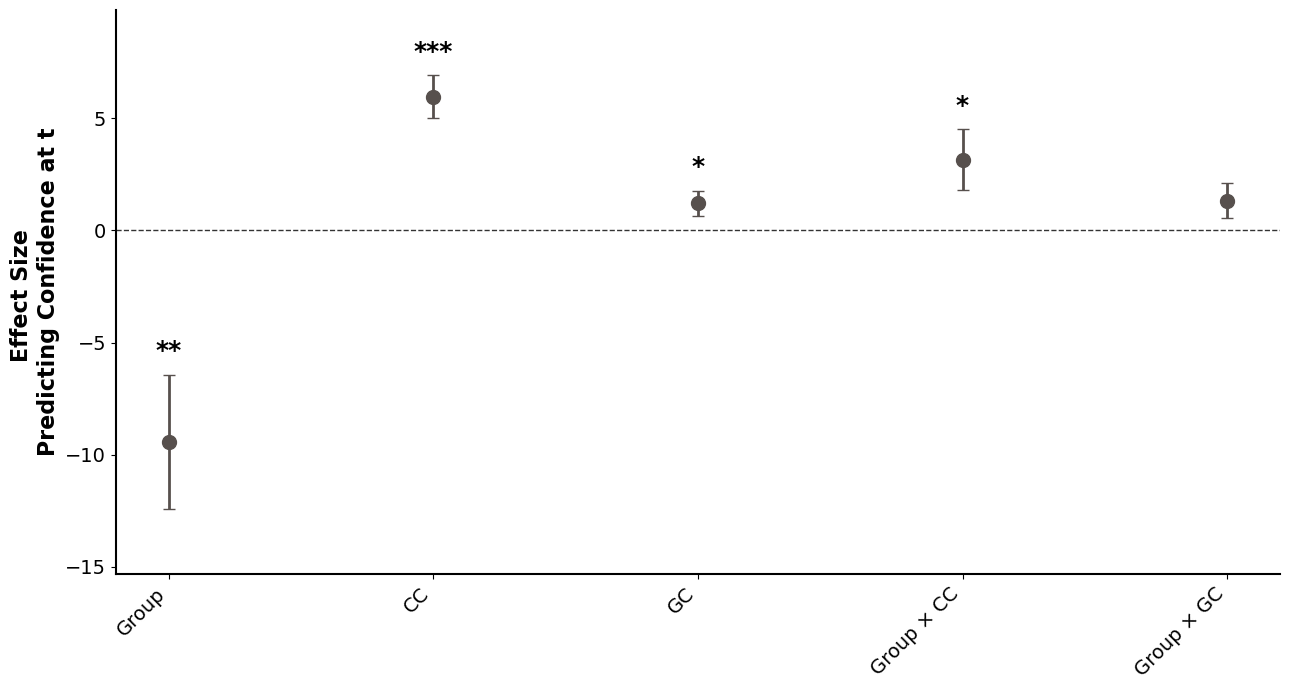

In [14]:
# ============================================================
# 0) Figure 4B
use_patientstatus = True

dot_color = '#57504d'  # your color

# ============================================================
# 1) PICK THE WINNING "ALL" MODEL BY BIC
# ============================================================
if 'modelsConf' not in globals():
    raise NameError("modelsConf not found. Fit models first so modelsConf[...] exists.")

pt_keys   = [k for k in modelsConf if k.startswith("All_PT_")]
nopt_keys = [k for k in modelsConf if k.startswith("All_NoPT_")]

if not pt_keys and not nopt_keys:
    raise ValueError("No 'All_PT_*' or 'All_NoPT_*' models found in modelsConf.")

def _best_by_bic(keys):
    ks = [k for k in keys if hasattr(modelsConf[k], 'BIC')]
    if not ks:
        raise ValueError("No models with BIC in the provided key set.")
    return min(ks, key=lambda k: modelsConf[k].BIC)

winner_key = _best_by_bic(pt_keys) if use_patientstatus else _best_by_bic(nopt_keys)
winner     = modelsConf[winner_key]

print(f"Using winning All model: {winner_key} | "
      f"AIC={winner.AIC:.3f}, BIC={winner.BIC:.3f}, LogLik={winner.logLike:.3f}")

# ============================================================
# 2) EXTRACT & PREP COEFFICIENTS (keep core terms, 3 decimals)
# ============================================================
coefs = winner.coefs.copy()

# drop intercept and demographic/task dummies from the plot
drop_patterns = ['(Intercept)', 'Intercept', 'age.sc', 'total_iq.sc', 'task_id', 'gender']
mask_drop = pd.Series(False, index=coefs.index)
for pat in drop_patterns:
    mask_drop = mask_drop | coefs.index.str.contains(rf'^{pat}$') | coefs.index.str.contains(pat)

coefs_plot = coefs[~mask_drop].copy()

# rename to pretty labels (only for plotting)
rename_map = {
    'patientstatus1': 'Group',
    'sum_prior_chosen_features.sc': 'CC',
    'prev_BLR_confidence.sc': 'GC',
    'patientstatus1:sum_prior_chosen_features.sc': 'Group × CC',
    'patientstatus1:prev_BLR_confidence.sc': 'Group × GC',
    'sum_prior_chosen_features': 'CC',
    'prev_BLR_confidence': 'GC',
    'patientstatus1:sum_prior_chosen_features': 'Group × CC',
    'patientstatus1:prev_BLR_confidence': 'Group × GC',
}

pretty_labels = []
for term in coefs_plot.index:
    if term in rename_map:
        pretty_labels.append(rename_map[term])
    elif ':' in term:
        # general fallback for interactions
        parts = term.split(':')
        pretty_labels.append(" ×\n".join(rename_map.get(p, p) for p in parts))
    else:
        pretty_labels.append(rename_map.get(term, term))
coefs_plot['Pretty'] = pretty_labels

# desired display order if present
desired_order = [
    'Group', 'CC', 'GC', 'Group × CC', 'Group × GC'
]
order_idx = []
for lab in desired_order:
    if lab in coefs_plot['Pretty'].values:
        order_idx.extend(coefs_plot.index[coefs_plot['Pretty'] == lab].tolist())
# append any leftovers (unlikely)
order_idx += [ix for ix in coefs_plot.index if ix not in order_idx]
coefs_plot = coefs_plot.loc[order_idx]

# Print a compact table (3 decimals) for reporting
print("\nKey coefficients (3 d.p.):")
show_terms = ['patientstatus1',
              'sum_prior_chosen_features.sc',
              'prev_BLR_confidence.sc',
              'patientstatus1:sum_prior_chosen_features.sc',
              'patientstatus1:prev_BLR_confidence.sc']
show_terms = [t for t in show_terms if t in coefs.index]
if show_terms:
    tbl = (coefs.loc[show_terms, ['Estimate','SE','P-val']]
                 .round(3)
                 .rename(index=rename_map))
    print(tbl.to_string())
else:
    print("(No patientstatus terms found; showing available non-demographic terms.)")
    print(coefs_plot[['Estimate','SE','P-val']].round(3).to_string())

# ============================================================
# 3) PLOT (ESTIMATE ± SE) WITH SIGNIFICANCE STARS
# ============================================================
def _sig_symbol(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(coefs_plot)) + 0.5
y = coefs_plot['Estimate'].values
yerr = coefs_plot['SE'].values
stars = [_sig_symbol(p) for p in coefs_plot['P-val'].values]

ax.errorbar(x, y, yerr=yerr, fmt='o', color=dot_color, ecolor=dot_color,
            elinewidth=2, capsize=4, markersize=10)
ax.axhline(0, linestyle='--', color='#333333', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(coefs_plot['Pretty'], rotation=45, ha='right', fontsize=14)
ax.set_ylabel('Effect Size \nPredicting Confidence at t', fontsize=16, fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
ax.margins(y=0.15)

# clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# significance stars above points
for xi, yi, ei, s in zip(x, y, yerr, stars):
    if s:
        ax.text(xi, yi + ei + 0.5, s, ha='center', va='bottom',
                fontsize=18, color='black', fontweight='bold')

plt.tight_layout()
plt.show()
